# Sales Data Analysis

**CloudExify Data Science Internship 2026 — Month 1, Project 1**

**Name:** Syed Haseeb Badshah

This notebook analyses a year of retail sales data with pandas: load it,
clean it, then answer the business questions — how sales move month by
month, which categories and regions bring in the money, and which products
sell best.

The dataset is synthetic (generated by `generate_data.py`) and made to look
like a Pakistani retail store: five categories, five regions, prices in Rs,
and a festival-season bump around Ramadan/Eid. Missing values and duplicate
rows were put in on purpose so the cleaning step is real work.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("sample_data/sales_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Rows:", len(df), "| Columns:", len(df.columns))
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.head()

Rows: 2615 | Columns: 9
Date range: 2025-01-01 to 2025-12-31


,OrderID,Date,Product,Category,Region,City,Units,UnitPrice,Amount
0,100415,2025-01-10,Electric Kettle,Home,Sindh,Karachi,3,3454.0,10362.0
1,100241,2025-09-08,Cookware Set,Home,Punjab,Multan,1,8633.0,8633.0
2,100262,2025-01-16,Jeans,Fashion,Punjab,Lahore,1,3272.0,3272.0
3,100609,2025-03-02,Lawn Suit,Fashion,Punjab,Rawalpindi,4,4469.0,17876.0
4,101514,2025-04-04,Wall Clock,Home,Punjab,Lahore,2,1464.0,2928.0


In [2]:
print("Column types:")
print(df.dtypes)
print()
df.describe()

Column types:
OrderID               int64
Date         datetime64[us]
Product                 str
Category                str
Region                  str
City                    str
Units                 int64
UnitPrice           float64
Amount              float64
dtype: object



,OrderID,Date,Units,UnitPrice,Amount
count,2615.000000,2615,2615.000000,2615.000000,2.595000e+03
mean,101300.033652,2025-07-02 10:54:44.741873,2.460038,14482.905163,3.679763e+04
min,100000.000000,2025-01-01 00:00:00,1.000000,1192.000000,1.192000e+03
25%,100649.500000,2025-04-02 00:00:00,1.000000,2501.000000,4.022500e+03
50%,101300.000000,2025-06-30 00:00:00,2.000000,3425.000000,7.836000e+03
75%,101952.500000,2025-09-30 00:00:00,3.000000,6367.000000,1.745250e+04
max,102599.000000,2025-12-31 00:00:00,11.000000,136876.000000,1.224090e+06
std,751.141702,NaN,1.505864,28578.925691,9.018570e+04


## 2. Data quality check

Three things to look for before trusting any number: missing values,
duplicate rows, and values that make no sense (zero or negative amounts).

In [3]:
print("Missing values per column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())
print("Rows with Amount <= 0:", (df["Amount"] <= 0).sum())
print("Categories:", df["Category"].unique().tolist())
print("Regions:", df["Region"].dropna().unique().tolist())

Missing values per column:
OrderID       0
Date          0
Product       0
Category      0
Region       20
City          0
Units         0
UnitPrice     0
Amount       20
dtype: int64

Exact duplicate rows: 15
Rows with Amount <= 0: 0
Categories: ['Home', 'Fashion', 'Grocery', 'Electronics']
Regions: ['Sindh', 'Punjab', 'KPK', 'Islamabad', 'Balochistan']


## 3. Clean the data

Three problems and how I handled each:

| Problem | Fix | Why |
|---|---|---|
| Duplicate rows | drop them | the same order counted twice inflates revenue |
| Missing `Amount` | recalculate as `Units × UnitPrice` | the information is still there in the other two columns, so dropping the rows would throw away good data |
| Missing `Region` | fill from the `City` column | every city belongs to exactly one region, so this is recoverable with certainty |

Dropping rows is the last resort, not the first move — here nothing had to
be dropped except the true duplicates.

In [4]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows left")

# Amount can be rebuilt from Units * UnitPrice
missing_amount = df["Amount"].isna().sum()
df["Amount"] = df["Amount"].fillna(df["Units"] * df["UnitPrice"])
print(f"Rebuilt {missing_amount} missing Amount values from Units x UnitPrice")

# Region can be recovered from City
city_to_region = (df.dropna(subset=["Region"])
                    .drop_duplicates("City")
                    .set_index("City")["Region"])
missing_region = df["Region"].isna().sum()
df["Region"] = df["Region"].fillna(df["City"].map(city_to_region))
print(f"Filled {missing_region} missing Region values from the City column")

print("\nMissing values now:")
print(df.isna().sum())

Dropped 15 duplicate rows -> 2600 rows left
Rebuilt 20 missing Amount values from Units x UnitPrice
Filled 20 missing Region values from the City column

Missing values now:
OrderID      0
Date         0
Product      0
Category     0
Region       0
City         0
Units        0
UnitPrice    0
Amount       0
dtype: int64


In [5]:
# helper columns for the monthly analysis
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.strftime("%b")

df.to_csv("sample_data/sales_data_clean.csv", index=False)
print("Cleaned data saved to sample_data/sales_data_clean.csv")
df.head()

Cleaned data saved to sample_data/sales_data_clean.csv


,OrderID,Date,Product,Category,Region,City,Units,UnitPrice,Amount,Month,MonthName
0,100415,2025-01-10,Electric Kettle,Home,Sindh,Karachi,3,3454.0,10362.0,1,Jan
1,100241,2025-09-08,Cookware Set,Home,Punjab,Multan,1,8633.0,8633.0,9,Sep
2,100262,2025-01-16,Jeans,Fashion,Punjab,Lahore,1,3272.0,3272.0,1,Jan
3,100609,2025-03-02,Lawn Suit,Fashion,Punjab,Rawalpindi,4,4469.0,17876.0,3,Mar
4,101514,2025-04-04,Wall Clock,Home,Punjab,Lahore,2,1464.0,2928.0,4,Apr


## 4. Headline numbers

The overall picture first, before breaking it down.

In [6]:
total_revenue = df["Amount"].sum()
total_orders = len(df)
total_units = df["Units"].sum()
avg_order = df["Amount"].mean()

print(f"Total revenue      : Rs {total_revenue:,.0f}")
print(f"Total orders       : {total_orders:,}")
print(f"Total units sold   : {total_units:,}")
print(f"Average order value: Rs {avg_order:,.0f}")
print(f"Largest single order: Rs {df['Amount'].max():,.0f}")

Total revenue      : Rs 94,969,121
Total orders       : 2,600
Total units sold   : 6,397
Average order value: Rs 36,527
Largest single order: Rs 1,224,090


## 5. Sales trend over the year

Monthly revenue shows the seasonality — which months a shop should stock up
for and which are quiet.

Best month : Mar (Rs 14.28M)
Worst month: Feb (Rs 4.60M)
The best month is 3.1x the worst.


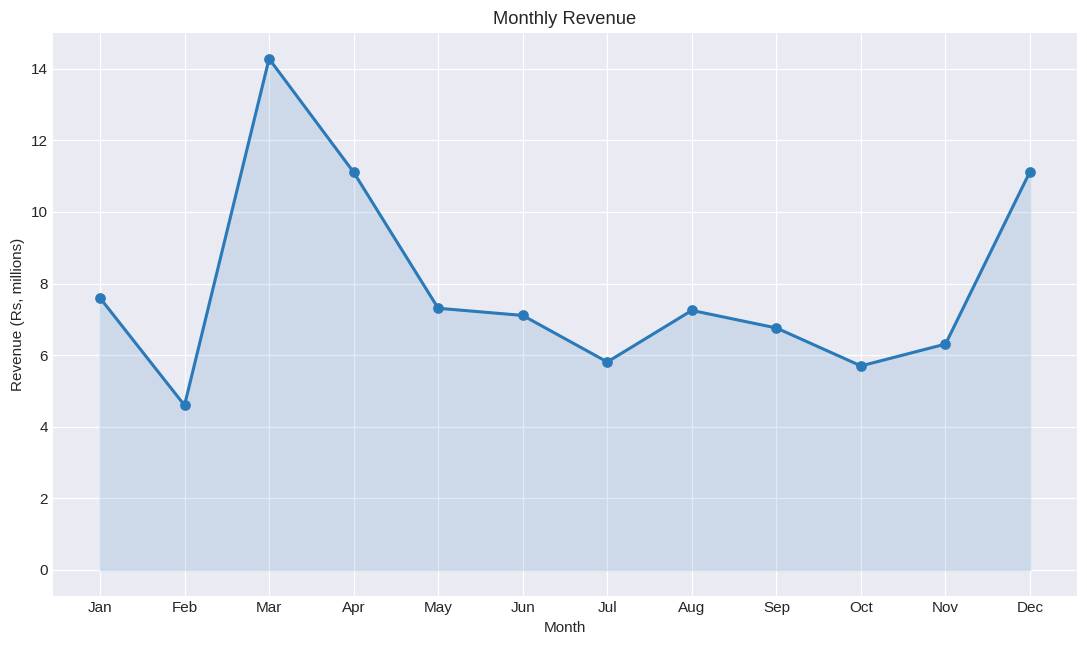

In [7]:
monthly = (df.groupby("Month")["Amount"].sum() / 1_000_000).round(2)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(monthly.index, monthly.values, "o-", color="#2a7ab9", linewidth=2)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color="#2a7ab9")
plt.xticks(range(1, 13), month_labels)
plt.xlabel("Month")
plt.ylabel("Revenue (Rs, millions)")
plt.title("Monthly Revenue")
plt.tight_layout()
plt.savefig("charts/monthly_revenue.png", dpi=110, bbox_inches="tight")
plt.show()

best, worst = monthly.idxmax(), monthly.idxmin()
print(f"Best month : {month_labels[best-1]} (Rs {monthly[best]:.2f}M)")
print(f"Worst month: {month_labels[worst-1]} (Rs {monthly[worst]:.2f}M)")
print(f"The best month is {monthly[best]/monthly[worst]:.1f}x the worst.")

## 6. Which categories earn the most?

In [8]:
by_category = (df.groupby("Category")
                 .agg(Revenue=("Amount", "sum"),
                      Orders=("OrderID", "count"),
                      Units=("Units", "sum"))
                 .sort_values("Revenue", ascending=False))
by_category["Share %"] = (by_category["Revenue"] /
                          by_category["Revenue"].sum() * 100).round(1)
by_category["Avg order"] = by_category["Revenue"] / by_category["Orders"]
print(by_category.round(0))

                Revenue  Orders  Units  Share %  Avg order
Category                                                  
Electronics  78284137.0     639   1588     82.0   122510.0
Home          7322389.0     686   1687      8.0    10674.0
Fashion       6255868.0     658   1606      7.0     9507.0
Grocery       3106727.0     617   1516      3.0     5035.0


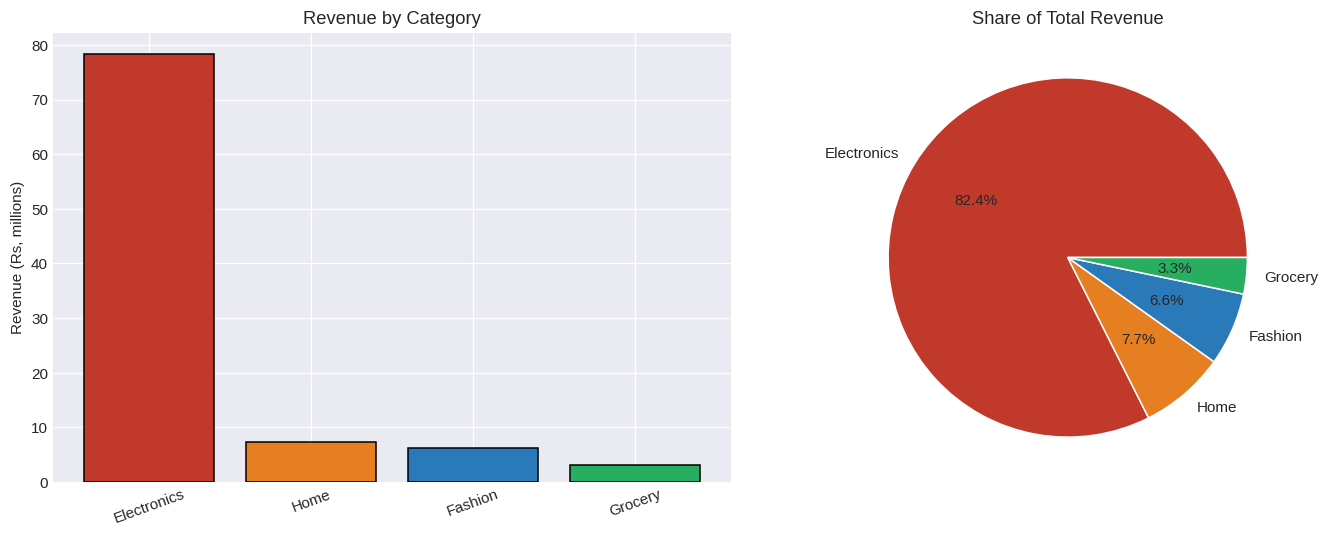

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cat_colors = ["#c0392b", "#e67e22", "#2a7ab9", "#27ae60"]
ax1.bar(by_category.index, by_category["Revenue"] / 1_000_000,
        color=cat_colors[:len(by_category)], edgecolor="black")
ax1.set_ylabel("Revenue (Rs, millions)")
ax1.set_title("Revenue by Category")
ax1.tick_params(axis="x", rotation=20)

ax2.pie(by_category["Revenue"], labels=by_category.index, autopct="%1.1f%%",
        colors=cat_colors[:len(by_category)],
        wedgeprops={"edgecolor": "white"})
ax2.set_title("Share of Total Revenue")

plt.tight_layout()
plt.savefig("charts/category_revenue.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Which regions and cities buy the most?

In [10]:
by_region = (df.groupby("Region")
               .agg(Revenue=("Amount", "sum"), Orders=("OrderID", "count"))
               .sort_values("Revenue", ascending=False))
by_region["Share %"] = (by_region["Revenue"] /
                        by_region["Revenue"].sum() * 100).round(1)
print(by_region.round(0))

print("\nTop 5 cities by revenue:")
print((df.groupby("City")["Amount"].sum()
         .sort_values(ascending=False).head(5).round(0)))

                Revenue  Orders  Share %
Region                                  
Punjab       38706668.0    1104     41.0
Sindh        30999735.0     805     33.0
Islamabad    11618137.0     236     12.0
KPK          10793395.0     340     11.0
Balochistan   2851186.0     115      3.0

Top 5 cities by revenue:
City
Karachi       13551945.0
Islamabad     11618137.0
Faisalabad    11485820.0
Rawalpindi     9405377.0
Lahore         9054639.0
Name: Amount, dtype: float64


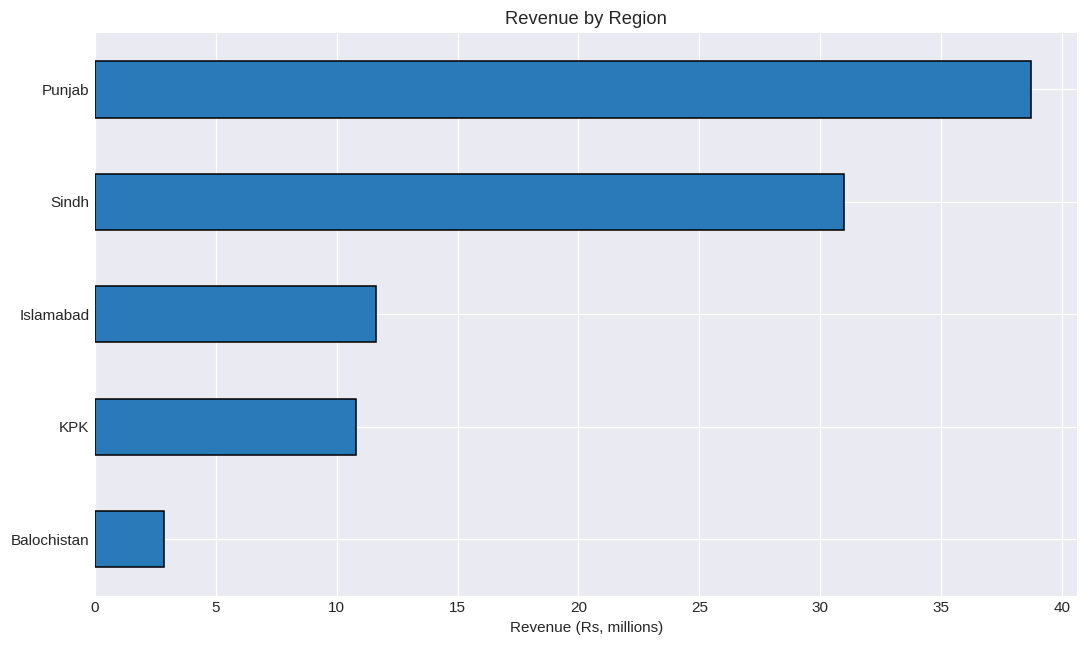

In [11]:
by_region["Revenue"].div(1_000_000).plot(
    kind="barh", color="#2a7ab9", edgecolor="black")
plt.xlabel("Revenue (Rs, millions)")
plt.ylabel("")
plt.title("Revenue by Region")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("charts/region_revenue.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Best selling products

Two different questions here: which products bring in the most **money**,
and which sell the most **units**. They are not the same list — expensive
electronics win on revenue, cheap groceries win on volume.

In [12]:
top_revenue = (df.groupby("Product")["Amount"].sum()
                 .sort_values(ascending=False).head(10))
top_units = (df.groupby("Product")["Units"].sum()
               .sort_values(ascending=False).head(10))

print("Top 10 products by revenue:")
print(top_revenue.round(0))
print("\nTop 10 products by units sold:")
print(top_units)

Top 10 products by revenue:
Product
Laptop               38825930.0
LED TV 43in          21495461.0
Smartphone           14866956.0
Cookware Set          3688631.0
Sneakers              2167619.0
Bluetooth Speaker     2152573.0
Lawn Suit             1691265.0
Bed Sheet Set         1679792.0
Electric Kettle       1373630.0
Jeans                 1351248.0
Name: Amount, dtype: float64

Top 10 products by units sold:
Product
Bed Sheet Set       441
Cookware Set        435
Electric Kettle     426
Jeans               423
Kurta               414
Sneakers            394
Wall Clock          385
Lawn Suit           375
Basmati Rice 5kg    357
LED TV 43in         333
Name: Units, dtype: int64


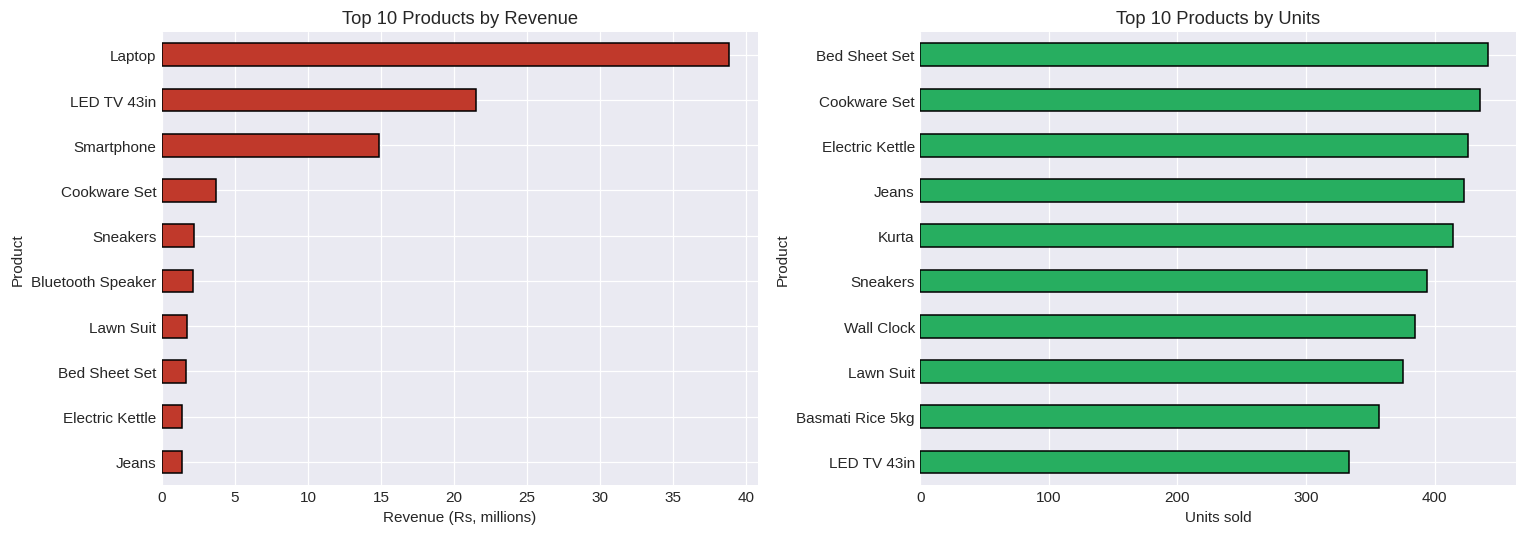

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top_revenue.sort_values().div(1_000_000).plot(
    kind="barh", ax=ax1, color="#c0392b", edgecolor="black")
ax1.set_xlabel("Revenue (Rs, millions)")
ax1.set_title("Top 10 Products by Revenue")

top_units.sort_values().plot(
    kind="barh", ax=ax2, color="#27ae60", edgecolor="black")
ax2.set_xlabel("Units sold")
ax2.set_title("Top 10 Products by Units")

plt.tight_layout()
plt.savefig("charts/top_products.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Category performance by month

A pivot table shows whether every category follows the same seasonal
pattern or if some peak at different times.

In [14]:
pivot = (df.pivot_table(index="Month", columns="Category",
                        values="Amount", aggfunc="sum")
           .div(1_000_000).round(2))
print("Revenue (Rs millions) by month and category:")
print(pivot)

Revenue (Rs millions) by month and category:
Category  Electronics  Fashion  Grocery  Home
Month                                        
1                6.47     0.30     0.26  0.56
2                3.43     0.50     0.17  0.50
3               12.24     0.79     0.36  0.89
4                9.20     0.62     0.36  0.93
5                6.08     0.34     0.17  0.73
6                5.81     0.46     0.33  0.52
7                4.56     0.49     0.21  0.54
8                6.00     0.39     0.25  0.61
9                5.79     0.47     0.22  0.29
10               4.52     0.48     0.25  0.45
11               4.76     0.67     0.22  0.65
12               9.42     0.76     0.30  0.65


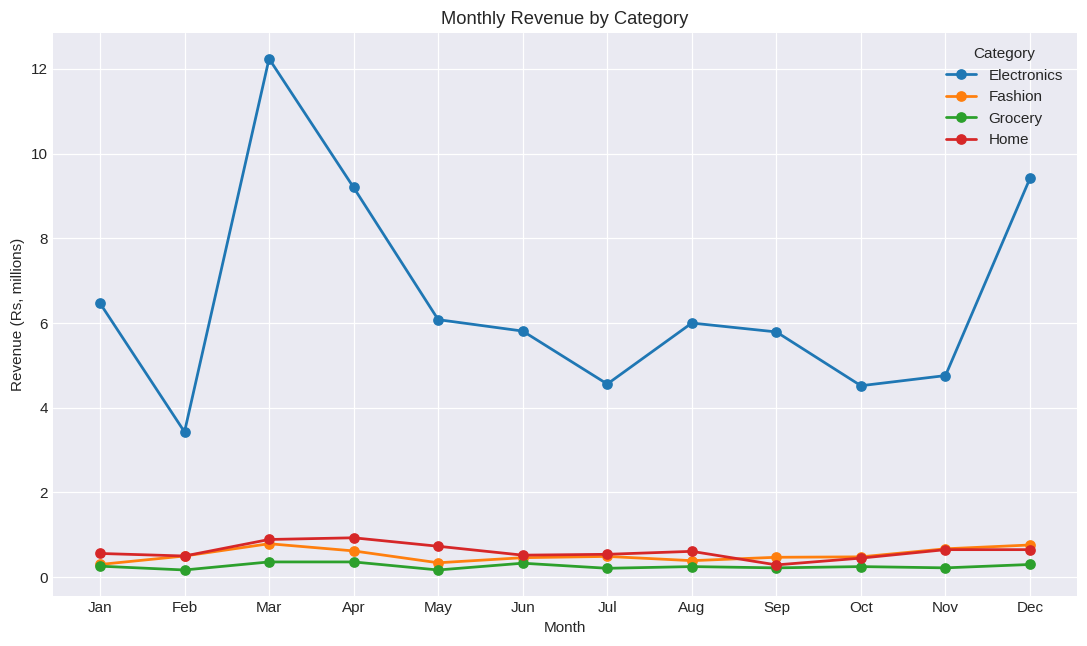

In [15]:
pivot.plot(kind="line", marker="o", linewidth=1.8)
plt.xticks(range(1, 13), month_labels)
plt.xlabel("Month")
plt.ylabel("Revenue (Rs, millions)")
plt.title("Monthly Revenue by Category")
plt.legend(title="Category")
plt.tight_layout()
plt.savefig("charts/category_by_month.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Summary report

In [16]:
lines = []
lines.append("=" * 60)
lines.append("SALES ANALYSIS REPORT")
lines.append("=" * 60)
lines.append(f"Period            : {df['Date'].min().date()} to "
             f"{df['Date'].max().date()}")
lines.append(f"Orders analysed   : {len(df):,}")
lines.append(f"Total revenue     : Rs {total_revenue:,.0f}")
lines.append(f"Average order     : Rs {avg_order:,.0f}")
lines.append("")
lines.append("TOP CATEGORY BY REVENUE")
lines.append("-" * 60)
for cat, row in by_category.iterrows():
    lines.append(f"{cat:<14} Rs {row['Revenue']:>12,.0f}  "
                 f"({row['Share %']:.1f}%)")
lines.append("")
lines.append("REVENUE BY REGION")
lines.append("-" * 60)
for reg, row in by_region.iterrows():
    lines.append(f"{reg:<14} Rs {row['Revenue']:>12,.0f}  "
                 f"({row['Share %']:.1f}%)")
lines.append("")
lines.append("BEST / WORST MONTH")
lines.append("-" * 60)
lines.append(f"Best : {month_labels[best-1]} (Rs {monthly[best]:.2f}M)")
lines.append(f"Worst: {month_labels[worst-1]} (Rs {monthly[worst]:.2f}M)")
lines.append("=" * 60)

report = "\n".join(lines)
print(report)

with open("sales_report.txt", "w", encoding="utf-8") as f:
    f.write(report + "\n")
print("\n[sales_report.txt saved]")

SALES ANALYSIS REPORT
Period            : 2025-01-01 to 2025-12-31
Orders analysed   : 2,600
Total revenue     : Rs 94,969,121
Average order     : Rs 36,527

TOP CATEGORY BY REVENUE
------------------------------------------------------------
Electronics    Rs   78,284,137  (82.4%)
Home           Rs    7,322,389  (7.7%)
Fashion        Rs    6,255,868  (6.6%)
Grocery        Rs    3,106,727  (3.3%)

REVENUE BY REGION
------------------------------------------------------------
Punjab         Rs   38,706,668  (40.8%)
Sindh          Rs   30,999,735  (32.6%)
Islamabad      Rs   11,618,137  (12.2%)
KPK            Rs   10,793,395  (11.4%)
Balochistan    Rs    2,851,186  (3.0%)

BEST / WORST MONTH
------------------------------------------------------------
Best : Mar (Rs 14.28M)
Worst: Feb (Rs 4.60M)

[sales_report.txt saved]


## 11. Findings

1. **Sales are seasonal.** Revenue climbs into the Ramadan/Eid months and
   again at the end of the year. Stock and staffing should follow that
   curve instead of being flat all year.
2. **Electronics carry the revenue, groceries carry the footfall.** The
   expensive categories dominate the money while cheap items dominate unit
   counts, so the two need different targets — margin for one, volume for
   the other.
3. **Sales are concentrated in a few big markets.** Punjab and Sindh
   together account for most of the revenue, which is where any marketing
   budget gets the most return; the smaller regions are a growth question,
   not a maintenance one.
4. **The cleaning step mattered.** Duplicate orders would have overstated
   revenue, and the missing values were recoverable from other columns
   rather than being a reason to drop rows.

*Caveat:* this is generated data, so these patterns are the ones that were
built into it. The method is what transfers to real data, not the numbers.